<a href="https://colab.research.google.com/github/FridaVargas/LABORATORIO-3/blob/main/ParteComputacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import matplotlib.pyplot as plt

## Gráficas de ejercicio 1

Quedamos que la suma parcial de $f$ está dada por:

$$
S_{M}f(\theta) = \sum_{n=0}^{M} \frac{8 \ sen((2n+1)\cdot \theta)}{\pi \cdot (2n+1)^{3} }
$$

Y queremos ver cómo lucen algunas sumas parciales, entonces vamos a graficarlas

In [10]:
l = 4
M = 2*l

# elegimos 100 puntos para graficar
teta = np.linspace(-np.pi, np.pi, 100)

# Hacemos la función de sumas parciales
def S_M(teta, M):
  # Aqui guardamos los valores que se van sumando para cada valor teta
  suma = np.zeros(100)
  for m in range(0,M+1):
    suma += 8*np.sin((2*m+1)*teta)/(np.pi*(2*m+1)**3)
  return suma


Con estas sumas parciales procedemos a graficar

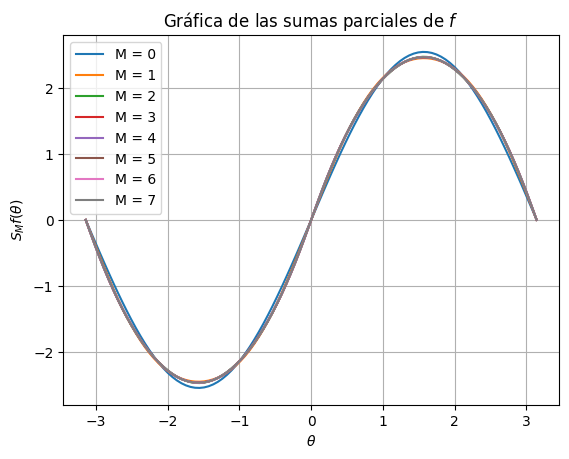

In [11]:
for m in range(M):
  plt.plot(teta, S_M(teta, m), label=f'M = {m}')
  plt.legend()
plt.grid()
plt.title(r'Gráfica de las sumas parciales de $f$')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$S_{M}f(\theta)$')
plt.show()



## Gráficas de sumas parciales de ejercicio 2

En este caso las sumas parciales están dadas por

$$
S_M f(\theta) = \frac{\pi^{2}}{12} + \sum_{n=1}^{M} \frac{ cos(n\theta)}{n^{2}}
$$

Cabe destacar que la suma $S_0 f = \frac{\pi^{2}}{12}$ y para $M$ mayores es la regla completa. Vamos a proceder entonces a realizar una función de las sumas parciales

In [12]:
# Hacemos la función de sumas parciales
def SS_M(teta, M):
  # Como S_0 es una constante, inicializamos la suma a ese valor
  suma = np.full(len(teta), (np.pi)**2/12)
  # Si solo queremos la suma S_0, la devolvemos
  if M == 0:
    return suma
  else:
    # De otra forma, seguimos sumando los términos correspondientes para cada teta
    for m in range(1,M+1):
      suma += np.cos(m*teta)/m**2
    return suma

Ahora graficamos algunos términos de las sumas parciales de f del ejercicio 2

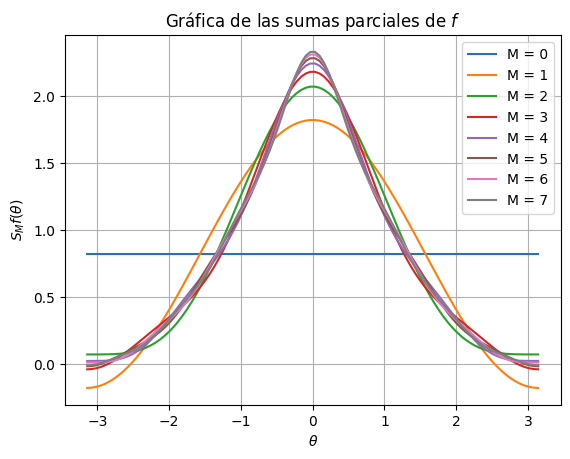

In [13]:
for m in range(M):
  plt.plot(teta, SS_M(teta, m), label=f'M = {m}')
  plt.legend()
plt.grid()
plt.title(r'Gráfica de las sumas parciales de $f$')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$S_{M}f(\theta)$')
plt.show()


## Implementación de algoritmo de la transformada discreta de Fourier (DFT)

Partimos de la definición vista en clase:

Dada la partición homogénea del intervalo $[-\pi, \pi]$ de $n$ puntos.

Sea $y = \{y_j\}_{j= - \infty}^{\infty}$ $2\pi-$periódica, su DFT es es la sucesión $(\mathcal{F}_n(y))_k = \hat{y}_{k}$, donde:

$$
\hat{y}_{k} = \sum_{j=0}^{n-1} y_{j} \cdot \text{exp}\left(- \frac{2\pi i}{n} j \ k \right)
$$

Luego, si definimos $\hat{y} = (\hat{y}_0, \ \hat{y}_1, \ldots, \hat{y}_{n-1})^{T}$, calcular la DFT es equivalente a calcular:

$$
\mathcal{F}_n(y) = \hat{y}= \bar{\mathcal{F}_n} \cdot y
$$


Donde $\bar{\mathcal{F}_n}$ es la matriz conjugada de $\mathcal{F}_n$, cuya entrada $(l,k)-$ésima es:

$$
\left[\mathcal{F}_n \right]_{l,k} = \text{exp}\left(\frac{2\pi i}{n} \right)^{(l-1)\cdot (k-1)}
$$

Ahora, para la transformada inversa de Fourier para recuperar la señal discreta original, $y$, basta con multiplicar por $\frac{1}{n}$ a la matriz $\mathcal{F}_n$

$$
y = \mathcal{F}_n^{-1} ( \hat{y}) = \frac{1}{n} \ \mathcal{F}_n \cdot \hat{y}
$$

In [14]:
#Vamos a crear una función que nos devuelva las matrices dada una n

def matrices_dft(n):
  # Empezamos por definir a w para encontrar las matrices
  w = np.exp(2j*np.pi/n)

  # Ahora hacemos matrices de nxn para F_n y su conjugada (avisando que guardaremos números complejos)
  Fn = np.zeros((n,n), dtype=np.complex128)
  Fn_conj = np.zeros((n,n), dtype=np.complex128)

  # Al ser una matriz simétrica F_n, la entrada l,k es la misma que k,l
  for l in range(n):
    for k in range(n):
      Fn[l,k]= w**(l*k)
      # Para las entradas de las matriz conjugada, nada mas conjugamos las entradas de la matriz
      Fn_conj[l,k]= np.conjugate(w**(l*k))

  return Fn, Fn_conj


## Ejercicio 3
1. Emplear el algoritmo de la transformada discreta de Fourier (DFT) para hacer una aproximación numérica de los dos ejercicios anteriores con oscilaciones de frecuencia hasta $n=2^5$.
2. Reconstruir la función original utilizando los coeficientes de Fourier aproximados para obtener un error de aproximación relativo menor que 0.01. ¿Cuántos coeficientes son necesarios para alcanzar esta tolerancia?
3. Describir el algoritmo, analizar y comparar con respecto a los resultados teóricos obtenidos en clase.

### Función de ejercicio 1
En este ejercicio se utilizó la siguiente función impar, continua en el círculo unitario

\begin{cases}
 f_1( \theta) = \theta \cdot (\pi - \theta) \quad \theta \in [0, \pi) \\
   \\
 f_2( \theta) = \theta \cdot (\pi + \theta) \quad \theta \in (-\pi,0)
\end{cases}

Primero grafiquemos esta función

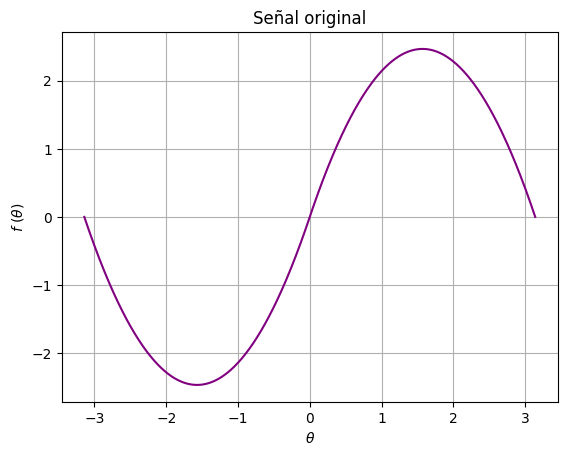

In [15]:
# Dominio de la función y muestreamos 1000 puntos para ahí evaluar la función
M = 1000
Teta = np.linspace(-np.pi, np.pi, M)

# Definimos las dos funciones
def f1(x):
    return x*(np.pi - x)

def f2(x):
    return x*(np.pi + x)

# La señal discretizada es la suma de f2 en los valores de -pi a 0 y f1 de 0 a pi
f = np.concatenate((f2(Teta[0:M//2]), f1(Teta[M//2:])))

# Mostramos la figura de la señal original
plt.figure()
plt.plot(Teta, f, c='purple')
plt.title('Señal original')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$f\ (\theta)$')
# Le graficamos ejes
plt.grid()
plt.show()

1. Emplear el algoritmo de la transformada discreta de Fourier (DFT) para hacer una aproximación numérica de los dos ejercicios anteriores con oscilaciones de frecuencia hasta $n=2^5$.

Dado que queremos oscilaciones hasta frecuencias de $n=2^5$ entonces la matriz $\mathcal{F}_{n}$ tiene que ser de al menos $(2^6, 2^{6})$.

In [40]:
# Queremos hasta la frecuencia n=2**5
n = 2**5
# Indices
k = np.arange(n)

# Usamos la funcion definida para encontrar las matrices, con al menos el doble de frecuencias que queremos tener
Fn, Fn_conj = matrices_dft(2*n)

# Ahora vamos a evaluar la funcion
t = np.linspace(-np.pi, np.pi, 2*n)

# Evaluamos la funcion en los puntos t
y = np.concatenate((f2(t[0:n]), f1(t[n:])))

# Calculamos la DFT de la señal
y_hat = Fn_conj @ y


Veamos el módulo de las $\hat{y}_k$ para los primeros 32 índices

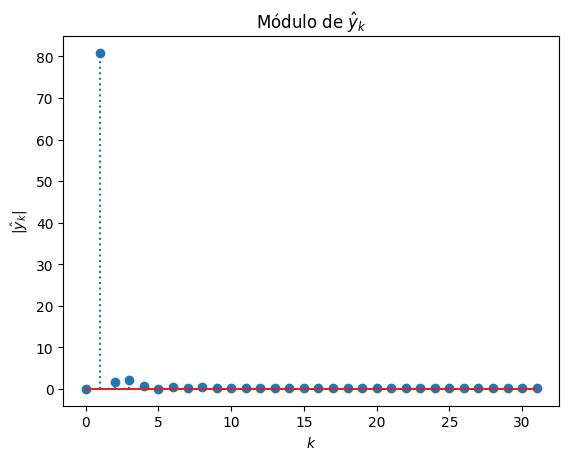

In [41]:
plt.stem(np.arange(32), np.abs(y_hat[:n]), ':')
plt.title(r'Módulo de $\hat{y}_k$')
plt.xlabel(r'$k$')
plt.ylabel(r'$|\hat{y}_k|$')
plt.show()


El hecho del que el puntito más alto sea el de $k=1$ quiere decir que la función $sen( \theta)$ está muy presente en la señal, de hecho nos dice que es la más presente. Y vemos cómo los demás decaen muy rápido, que es esperable por cómo converge la serie de fourier en este ejemplo.


2. Reconstruir la función original utilizando los coeficientes de Fourier aproximados para obtener un error de aproximación relativo menor que 0.01. ¿Cuántos coeficientes son necesarios para alcanzar esta tolerancia?

En este caso no hace falta hacer cálculos complejos pues ya vimos que casi todo el aporte de la señal es de $\hat{y}_1$ entonces muy seguramente basta con tomar en cuenta esa sólo las dos primeras $k$ para tener un error relativo menor a 0.01.

Entonces las funciones debemos de construirlas (4x4)

In [42]:
# Usamos la funcion definida para encontrar las matrices
Fn2, Fn_conj2 = matrices_dft(4)

# Ahora vamos a evaluar la funcion
t2 = np.linspace(-np.pi, np.pi, 4)

# Evaluamos la funcion en los puntos t
y2 = np.concatenate((f2(t2[0:2]), f1(t2[2:])))

# Calculamos la DFT de la señal
y_hat2 = Fn_conj2 @ y2

# Reconstruimos la señal con la matriz F_n
y_rec2 = ((1/(4))*Fn2) @ y_hat2

Ahora con los puntos que tenemos calculamos el error relativo en norma $l^{2}$ para el espacio discreto

In [43]:
np.linalg.norm(y_rec2-y2)/np.linalg.norm(y2)

np.float64(2.2130188237998872e-16)

Y el error es pequeñísimo, más que la tolerancia de 0.01 entonces nuestra intuición estuvo correcta.

Para tener una gráfica bonita en este inciso podemos graficar la función reconstruida con los primeros 32 índices.

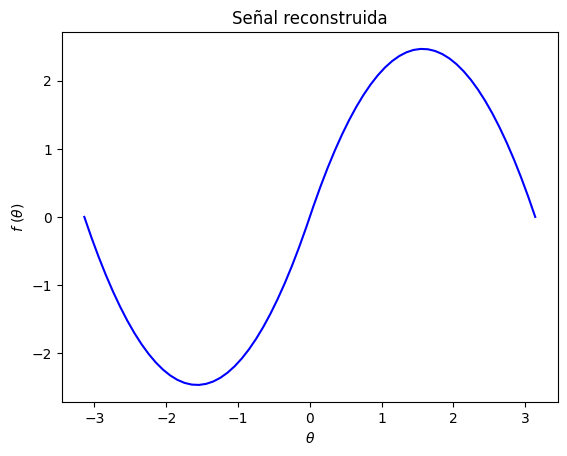

In [45]:
# Reconstruimos la señal con la matriz F_n. Aqui usamos 2n porque en realidad es
# el tamaño de la matriz Fn (2n x 2n)
y_rec = ((1/(2*n))*Fn) @ y_hat

# Graficamos la señal reconstruida
plt.figure()
plt.plot(t, y_rec, color="blue")
plt.title('Señal reconstruida')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$f\ (\theta)$')

plt.show()

3. Describir el algoritmo, analizar y comparar con respecto a los resultados teóricos obtenidos en clase.

Se comportó de manera muy esperable de acuerdo a lo obtenido teóricamente, pues la serie de Fourier de esta función es

$$
\sum_{n=0}^{\infty} \frac{8 \ sen((2n+1) \cdot \theta)}{\pi \ (2n+1)^{3}}
$$

Y el término más grande es $\frac{8 \ sen(\theta)}{\pi}$, que coincide con lo que encontramos y señalamos en la gráfica de los $\hat{y}_k$.Además esto tambié justifica por qué bastó con un índice pequeño para obtener un error relativo minúsculo.


### Función de ejercicio 2
En este ejercicio se utilizó la siguiente función par, continua en el círculo unitario

\begin{cases}
 g_1( \theta) = \frac{(\pi - \theta)^{2}}{4} \quad \theta \in [0, \pi) \\
   \\
 g_2( \theta) = \frac{(\pi + \theta)^{2}}{4} \quad \theta \in (-\pi,0)
\end{cases}

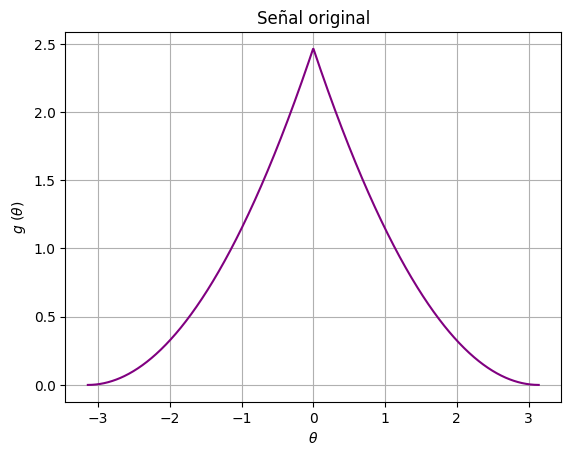

In [21]:
# Dominio de la función y muestreamos 1000 puntos para ahí evaluar la función
M = 1000
Teta = np.linspace(-np.pi, np.pi, M)

# Definimos las dos funciones
def g1(x):
    return ((np.pi - x)**2)/4

def g2(x):
    return ((np.pi + x)**2)/4

# La señal discretizada es la suma de f2 en los valores de -pi a 0 y f1 de 0 a pi
g = np.concatenate((g2(Teta[0:M//2]), g1(Teta[M//2:])))

# Mostramos la figura de la señal original
plt.figure()
plt.plot(Teta, g, c='purple')
plt.title('Señal original')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$g\ (\theta)$')
# Le graficamos ejes
plt.grid()
plt.show()

1. Emplear el algoritmo de la transformada discreta de Fourier (DFT) para hacer una aproximación numérica de los dos ejercicios anteriores con oscilaciones de frecuencia hasta $n=2^5$.

Dado que queremos oscilaciones hasta frecuencias de $n=2^5$ entonces la matriz $\mathcal{F}_{n}$ tiene que ser de al menos $(2^6, 2^{6})$.

In [22]:
# Queremos hasta la frecuencia n=2**5
n = 2**5
# Indices
k = np.arange(n)

# Usamos la funcion definida para encontrar las matrices, con al menos el doble de frecuencias que queremos tener
Fn, Fn_conj = matrices_dft(2*n)

# Ahora vamos a evaluar la funcion
t = np.linspace(-np.pi, np.pi, 2*n)

# Evaluamos la funcion en los puntos t
h = np.concatenate((g2(t[0:n]), g1(t[n:])))

# Calculamos la DFT de la señal
h_hat = Fn_conj @ h


Veamos el módulo de los $\hat{y}_{k}$ de los primeros 32 índices

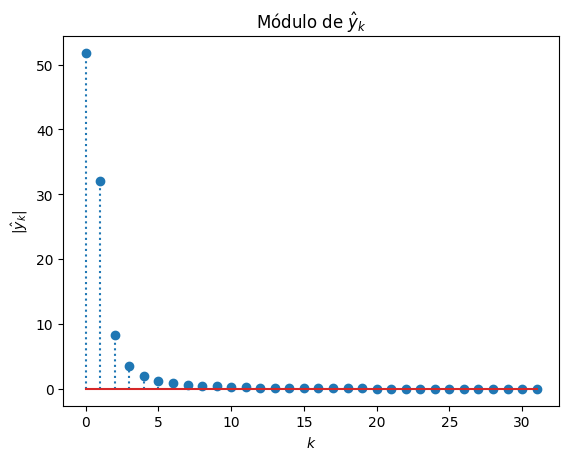

In [23]:
plt.stem(np.arange(32), np.abs(h_hat[:n]), ':')
plt.title(r'Módulo de $\hat{y}_k$')
plt.xlabel(r'$k$')
plt.ylabel(r'$|\hat{y}_k|$')
plt.show()

También observamos un decaimiento, que es esperable pues los términos de la serie decaen rápidamente a cero en este ejercicio también, pero lo interesante es que vemos que hay otras funciones con más aportaciones a la señal que estamos evaluando, a diferencia del primer ejercicio. Dado que es una función par, observamos que las funciones $cos(0), cos(\theta), \cos(2\theta)$ aportan fuertemente a la señal estudiada.

2. Reconstruir la función original utilizando los coeficientes de Fourier aproximados para obtener un error de aproximación relativo menor que 0.01. ¿Cuántos coeficientes son necesarios para alcanzar esta tolerancia?

Vamos a reconstruir la señal usando $k$ que va a variar desde cero hasta 4, y en cada reconstrucción calculamos el error relativo.

In [24]:

for k in range(1,5):
  # Tamaño del muestreo y la matriz
  n=2*k
  Fnn, Fn_conjj = matrices_dft(n)

  # Ahora vamos a evaluar la funcion
  t = np.linspace(-np.pi, np.pi, n)

  # Evaluamos la funcion en los puntos t
  Y = np.concatenate((g2(t[0:k]), g1(t[k:])))

  # Calculamos la DFT de la señal
  Y_hat = Fn_conjj @ Y

  # Reconstruimos la señal con la matriz F_n
  Y_rec = ((1/(n))*Fnn) @ Y_hat

  # Calculamos el error relativo
  error = np.linalg.norm(Y_rec-Y)/np.linalg.norm(Y)

  print(f"Error relativo para k = {k}: {error}")


Error relativo para k = 1: nan
Error relativo para k = 2: 2.0217248991458213e-16
Error relativo para k = 3: 5.240777944055464e-16
Error relativo para k = 4: 8.456968535323753e-16


/tmp/ipykernel_172539/3814076269.py:19: RuntimeWarning: invalid value encountered in scalar divide
  error = np.linalg.norm(Y_rec-Y)/np.linalg.norm(Y)


El error relativo de k=1 posiblemente es porque se tienen sólo dos puntos del muestreo y como coinciden entonces se da una división de cero entre cero. Los demás puntos nos muestran que de igual forma para k igual a dos, la reconstrucción tiene un error menor a 0.01

Terminamos con la comparación de la gráfica de $g$ junto con la señal reconstruida hasta el índice $k=5$

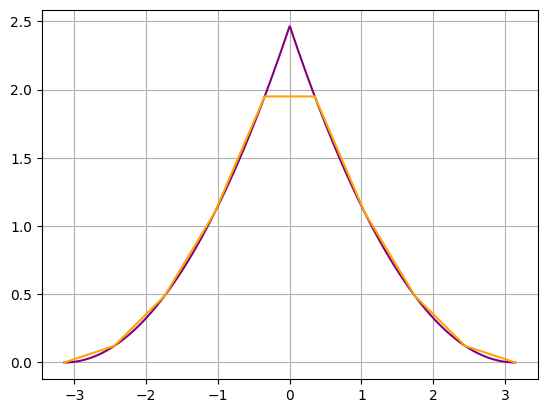

In [25]:
  k=5
  n=2*k
  Fnn, Fn_conjj = matrices_dft(n)

  # Ahora vamos a evaluar la funcion
  t = np.linspace(-np.pi, np.pi, n)

  # Evaluamos la funcion en los puntos t
  Y = np.concatenate((g2(t[0:k]), g1(t[k:])))

  # Calculamos la DFT de la señal
  Y_hat = Fn_conjj @ Y

  # Reconstruimos la señal con la matriz F_n
  Y_rec = ((1/(n))*Fnn) @ Y_hat

  plt.plot(Teta, g, c='purple')
  plt.plot(t, Y_rec, c='orange')
  plt.grid()
  plt.show()

## Ejercicio 4
Emplear el algoritmo DFT para hacer una aproximación numérica con oscilaciones de frecuencia hasta $n=2^{6}$ de la señal $f:[0,2\pi] \longrightarrow \mathbb{R}$ dada por:

$$
f(t)= \text{exp}\left( - \frac{t^{2}}{10} \right) \ \left( sin(2t)+ 2cos(4t)+0.4sin(t)\cdot sin(50t) \right)
$$

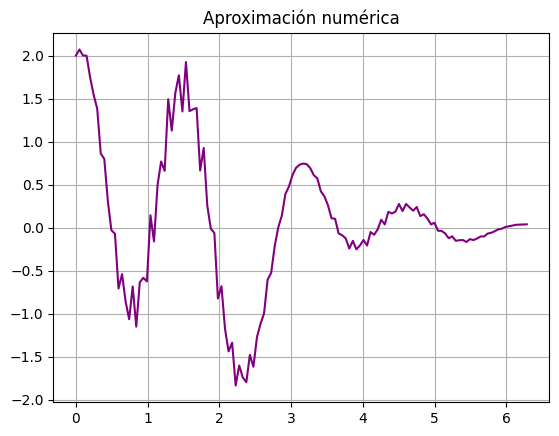

In [26]:
# Definimos la función
def F(t):
  return np.exp(-t**2/10)*(np.sin(2*t)+2*np.cos(4*t)+0.4*np.sin(t)*np.sin(50*t))

# Si queremos hasta la frecuencia 2**6, necesitamos la matriz Fn de (2**7, 2**7)
fn, fn_conj = matrices_dft(2**7)

# Definimos el dominio t
t = np.linspace(0, 2*np.pi, 2**7)

# Evaluamos la funcion en los puntos t
y3 = F(t)

# Calculamos la DFT de la señal
y_hat3 = fn_conj @ y3

# Calculamos su inversa
y_rec3 = ((1/(2**7))*fn) @ y_hat3

# Graficamos la aproximación
plt.plot(t, y_rec3, c='purple')
plt.title('Aproximación numérica')
plt.grid()
plt.show()


Para $n=2^8$, considera la sucesión discreta de $f: y_k = f(t_k)$ donde $t_k=\frac{2k\pi}{n}$. Usar el algoritmo de la DFT para filtrar los términos de alta frecuencia $(k \geq m)$, para los siguientes casos:

1. $m\geq 6$
2. $m\geq 12$

A través de la transformada inversa, obtener la señal filtrada. Dibujar los gráficos de la señal discreta, el valor absoluto de los coeficientes de Fourier y la señal filtrada. En cada uno de los casos calcular el error relativo

In [27]:
N = 2**8
K = np.arange(2**8)

# Definimos el vector tiempo como nos indicaron
tt = np.array([2*k*np.pi/N for k in K])

# Invocamos las matrices Fn y su conjugada
Fn4, Fn_conj4 = matrices_dft(2**8)

# Calculamos la funcion F en los puntos del tiempo
y4 = F(tt)

# Calculamos la DFT
y_hat4 = Fn_conj4 @ y4

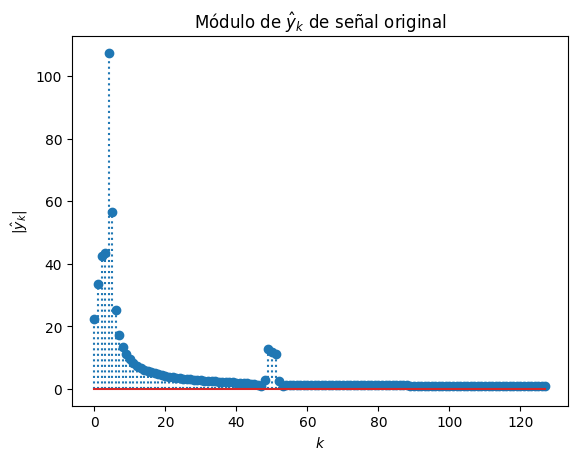

In [28]:
plt.stem(K[:2**7], np.abs(y_hat4[:2**7]), ':')
plt.title(r'Módulo de $\hat{y}_k$ de señal original')
plt.xlabel(r'$k$')
plt.ylabel(r'$|\hat{y}_k|$')
plt.show()

Vamos a proceder a filtrar las señales haciendo cero los $\hat{y}_k$ tal que la $k \geq m$ de las $m$ establecidas para (A) y (B).

In [29]:
# Aquí guardamos los valores de y_hat de las señales filtradas
y_filtrada_a = np.zeros(2**8, dtype=np.complex128)
y_filtrada_b = np.zeros(2**8, dtype=np.complex128)

# Para el inciso A solo queremos las que son iguales o menores a k=6
for m in range(7):
  y_filtrada_a[m] = y_hat4[m]
  # Recuperamos las ultimas porque la DFT es simétrica
  y_filtrada_a[-m] = y_hat4[-m]

# Lo mismo hacemos para el inciso B donde queremos las menores a k=12
for m in range(12):
  y_filtrada_b[m] = y_hat4[m]
  y_filtrada_b[-m] = y_hat4[-m]

Vemos si lo hicimos bien al graficar el módulo de $\hat{y}_k$ para las señales filtradas

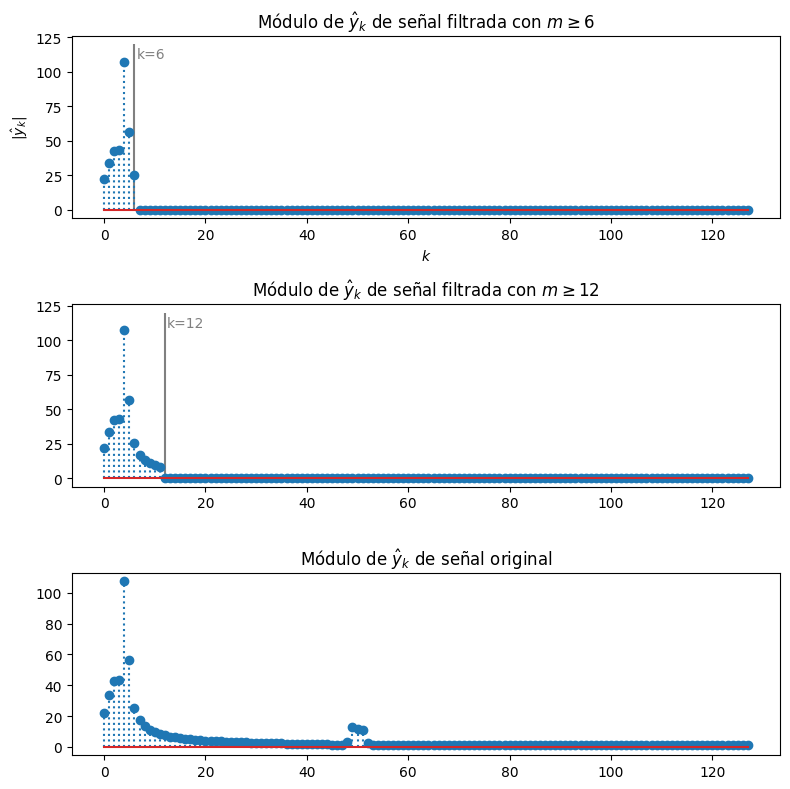

In [30]:
fig, axs = plt.subplots(3,1, figsize=(8, 8))
axs[0].vlines(x=6, ymin=0, ymax=120, color='gray')
axs[0].text(6.4, 110, 'k=6', color='gray')
axs[0].stem(K[:2**7], np.abs(y_filtrada_a[:2**7]), ':')
axs[0].set_title(r'Módulo de $\hat{y}_k$ de señal filtrada con $m \geq 6$')
axs[0].set_xlabel(r'$k$')
axs[0].set_ylabel(r'$|\hat{y}_k|$')

axs[1].vlines(x=12, ymin=0, ymax=120, color='gray')
axs[1].text(12.4, 110, 'k=12', color='gray')
axs[1].stem(K[:2**7], np.abs(y_filtrada_b[:2**7]), ':')
axs[2].stem(K[:2**7], np.abs(y_hat4[:2**7]), ':')
axs[1].set_title(r'Módulo de $\hat{y}_k$ de señal filtrada con $m \geq 12$')
axs[2].set_title(r'Módulo de $\hat{y}_k$ de señal original')
fig.tight_layout()
plt.show()

Vemos que efectivamente, todos los términos de frecuencias mayores se anularon.

Seguimos con reconsruir las señales filtradas con la transformada inversa de fourier

In [31]:
# Reconstruimos la señal original, las señales recontruidas en A y en B
y_rec_a = ((1/(2**8))*Fn4) @ y_filtrada_a
y_rec_b = ((1/(2**8))*Fn4) @ y_filtrada_b
y_recc = ((1/(2**8))*Fn4) @ y_hat4

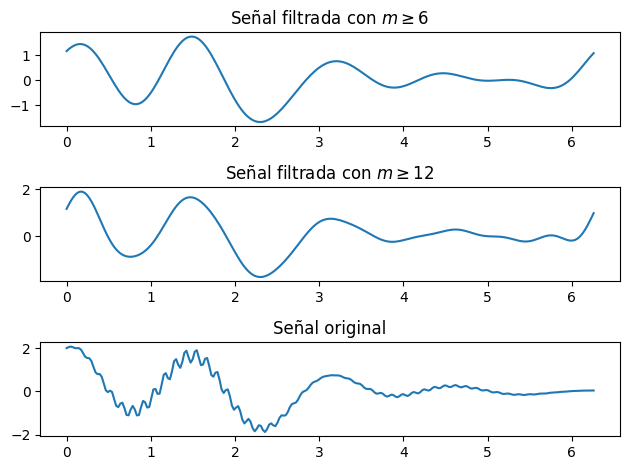

In [32]:
# Graficamos (3,1) las 3 señales reconstruidas que obtuvimos
fig, axs = plt.subplots(3)
axs[0].plot(tt, y_rec_a)
axs[0].set_title(r'Señal filtrada con $m \geq 6$')

axs[1].plot(tt, y_rec_b)
axs[1].set_title(r'Señal filtrada con $m \geq 12$')

axs[2].plot(tt, y_recc)
axs[2].set_title(r'Señal original')

fig.tight_layout()
plt.show()

Grafiquemos conjuntamente los módulos y las señales

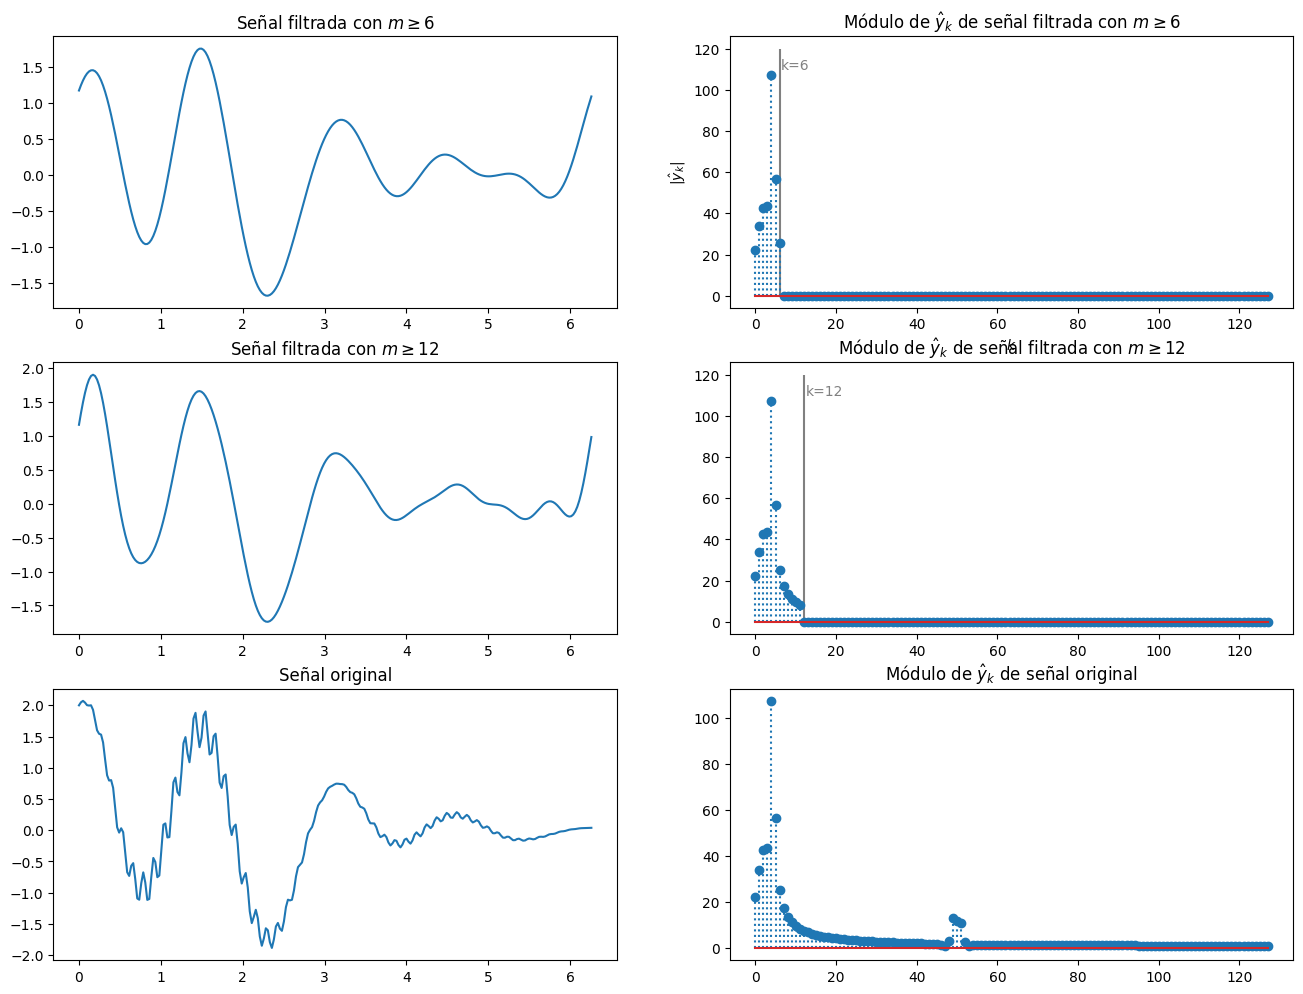

In [33]:
figs, axs = plt.subplots(3,2, figsize=(16, 12))
axs[0,0].plot(tt, y_rec_a)
axs[0,0].set_title(r'Señal filtrada con $m \geq 6$')

axs[1,0].plot(tt, y_rec_b)
axs[1,0].set_title(r'Señal filtrada con $m \geq 12$')

axs[2,0].plot(tt, y_recc)
axs[2,0].set_title(r'Señal original')

axs[0,1].vlines(x=6, ymin=0, ymax=120, color='gray')
axs[0,1].text(6.4, 110, 'k=6', color='gray')
axs[0,1].stem(K[:2**7], np.abs(y_filtrada_a[:2**7]), ':')
axs[0,1].set_title(r'Módulo de $\hat{y}_k$ de señal filtrada con $m \geq 6$')
axs[0,1].set_xlabel(r'$k$')
axs[0,1].set_ylabel(r'$|\hat{y}_k|$')

axs[1,1].vlines(x=12, ymin=0, ymax=120, color='gray')
axs[1,1].text(12.4, 110, 'k=12', color='gray')
axs[1,1].stem(K[:2**7], np.abs(y_filtrada_b[:2**7]), ':')
axs[2,1].stem(K[:2**7], np.abs(y_hat4[:2**7]), ':')
axs[1,1].set_title(r'Módulo de $\hat{y}_k$ de señal filtrada con $m \geq 12$')
axs[2,1].set_title(r'Módulo de $\hat{y}_k$ de señal original')
fig.tight_layout()
plt.show()

Terminamos por calcular el error relativo de cada una de las tres señales

In [34]:
# Para la señal original
er1 = np.linalg.norm(y4 - y_recc)/np.linalg.norm(y4)

# Para la señal filtrada en B
er2 = np.linalg.norm(y4 - y_rec_b)/np.linalg.norm(y4)

# Para la señal filtrada en A
er3 = np.linalg.norm(y4 - y_rec_a)/np.linalg.norm(y4)

print(f"Error relativo de la señal original: {er1}")
print(f"Error relativo de la señal filtrada en B: {er2}")
print(f"Error relativo de la señal filtrada en A: {er3}")

Error relativo de la señal original: 8.280990926777893e-13
Error relativo de la señal filtrada en B: 0.212110149335728
Error relativo de la señal filtrada en A: 0.2816870217013232


Tiene mucho sentido que la señal filtrada en A tenga un error relativo más grande porque estamos truncando a partir de frecuencias más pequeñas.